# VAL-02: K-means 최적 K 검증

**선행 조건**: `val_01_data.ipynb` 실행 완료 (`notebook/data/df_feat_clean.csv` 존재)

**목적**:
- Elbow Method 로 관성(Inertia) 감소 추이 확인
- Silhouette Score 로 최적 K 정량 판단
- K=6 선택의 수치적 근거 확인 (Silhouette best score)

**출력**: `notebook/data/cluster_assignments.csv` (district, year, cluster)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings, platform
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    try:
        fe = fm.FontEntry(fname=font_path, name='NanumGothic')
        fm.fontManager.ttflist.insert(0, fe)
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        pass
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print('라이브러리 로딩 완료')

라이브러리 로딩 완료


---
## 1. 데이터 로딩

In [4]:
import os
assert os.path.exists('data/df_feat_clean.csv'), '❌ val_01_data.ipynb 먼저 실행하세요'

df_feat = pd.read_csv('data/df_feat_clean.csv', encoding='utf-8-sig')

FEATURE_COLS = [
    'total_resident_population', 'total_households', 'gas_supply_ratio',
    'home_ratio', 'public_ratio', 'service_ratio', 'industry_ratio'
]

print(f'df_feat: {df_feat.shape}')
print(f'연도: {sorted(df_feat.year.unique())}')
print(f'자치구 수: {df_feat.district.nunique()}')
print(f'결측치: {df_feat[FEATURE_COLS].isnull().sum().sum()}개')

df_feat: (150, 9)
연도: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
자치구 수: 25
결측치: 0개


---
## 2. 스케일링

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(df_feat[FEATURE_COLS])

print(f'X shape: {X.shape}')
print(f'X 평균 (≈0): {X.mean(axis=0).round(6)}')
print(f'X 표준편차 (≈1): {X.std(axis=0).round(6)}')

X shape: (150, 7)
X 평균 (≈0): [-0.  0.  0. -0. -0. -0.  0.]
X 표준편차 (≈1): [1. 1. 1. 1. 1. 1. 1.]


---
## 3. Elbow + Silhouette

In [6]:
K_TARGET = 6          
K_RANGE  = range(2, 11)  
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    print(f'  K={k}  Inertia={km.inertia_:>10.2f}  Silhouette={sil_scores[-1]:.4f}')

k_list      = list(K_RANGE)
best_k      = k_list[sil_scores.index(max(sil_scores))]
target_sil  = sil_scores[k_list.index(K_TARGET)]
best_sil    = max(sil_scores)

print()
print(f'K={K_TARGET} Silhouette: {target_sil:.4f}')
print(f'최적 K={best_k}  Silhouette: {best_sil:.4f}')

Exception in thread Thread-3 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\vacke\anaconda3\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "c:\Users\vacke\anaconda3\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "c:\Users\vacke\anaconda3\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vacke\anaconda3\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "<frozen codecs>", line 325, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xba in position 24: invalid start byte
  File "c:\Users\vacke\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 262, in _count_physical_cores
    cpu_info = cpu_info.stdout.splitlines()
               ^^^^^^^^^^^^^^^^^

  K=2  Inertia=    734.67  Silhouette=0.3322
  K=3  Inertia=    560.44  Silhouette=0.2728
  K=4  Inertia=    445.12  Silhouette=0.3075
  K=5  Inertia=    375.29  Silhouette=0.3339
  K=6  Inertia=    320.57  Silhouette=0.3492
  K=7  Inertia=    277.86  Silhouette=0.3752
  K=8  Inertia=    236.60  Silhouette=0.4080
  K=9  Inertia=    200.31  Silhouette=0.4202
  K=10  Inertia=    166.24  Silhouette=0.4509

K=6 Silhouette: 0.3492
최적 K=10  Silhouette: 0.4509


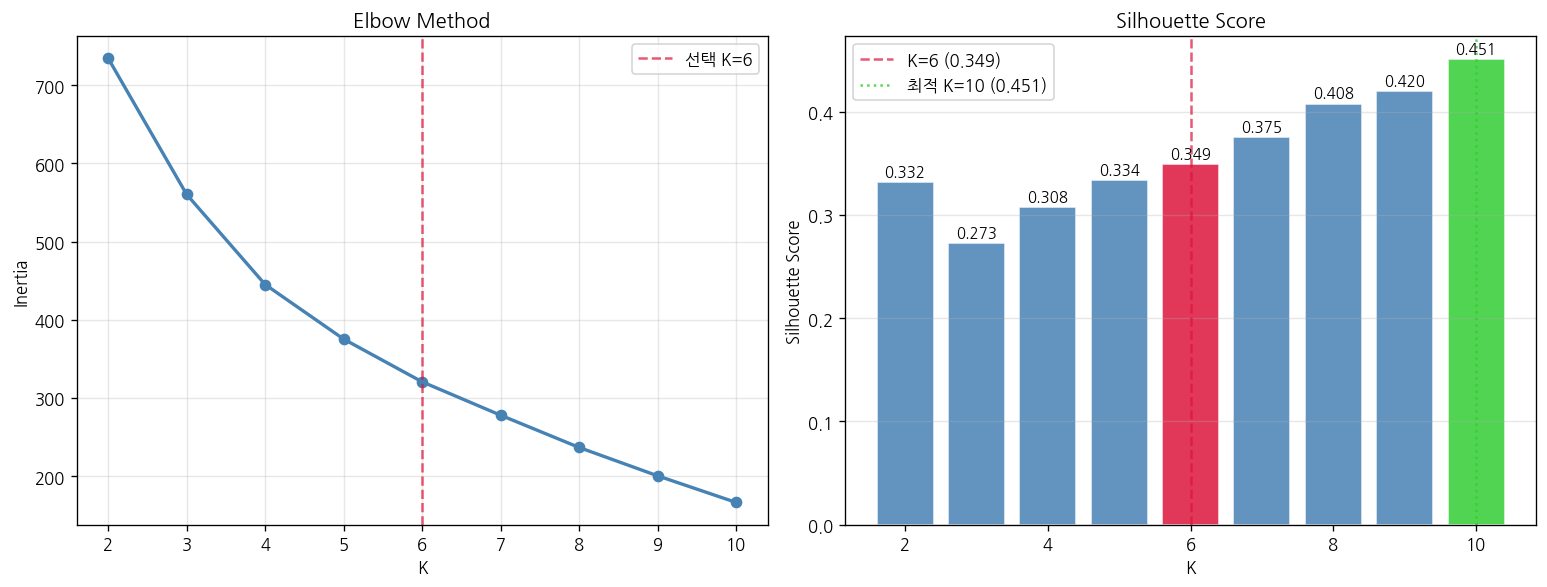


→ ⚠️  Silhouette 최적은 K=10 (점수 손실 0.1017)


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))


ax1.plot(k_list, inertias, 'o-', color='steelblue', linewidth=2)
ax1.axvline(K_TARGET, color='crimson', linestyle='--', alpha=0.7, label=f'선택 K={K_TARGET}')
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method'); ax1.legend(); ax1.grid(alpha=0.3)


colors_bar = ['crimson' if k == K_TARGET else ('limegreen' if k == best_k and k != K_TARGET else 'steelblue') for k in k_list]
bars = ax2.bar(k_list, sil_scores, color=colors_bar, alpha=0.85, edgecolor='white')
for bar, s in zip(bars, sil_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{s:.3f}', ha='center', va='bottom', fontsize=9)
ax2.axvline(K_TARGET, color='crimson', linestyle='--', alpha=0.7, label=f'K={K_TARGET} ({target_sil:.3f})')
if best_k != K_TARGET:
    ax2.axvline(best_k, color='limegreen', linestyle=':', alpha=0.8, label=f'최적 K={best_k} ({best_sil:.3f})')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score'); ax2.legend(); ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print()
if best_k == K_TARGET:
    print(f'→ ✅ K={K_TARGET}이 Silhouette 기준 최적값.')
else:
    loss = best_sil - target_sil
    print(f'→ ⚠️  Silhouette 최적은 K={best_k} (점수 손실 {loss:.4f})')

---
## 4. K=6 군집 할당 & PCA 시각화

In [8]:
km_target = KMeans(n_clusters=K_TARGET, random_state=42, n_init=10)
labels_target = km_target.fit_predict(X)

df_feat = df_feat.copy()
df_feat['cluster'] = labels_target

print(f'K={K_TARGET} Silhouette: {silhouette_score(X, labels_target):.4f}')
print(f'군집별 관측치 수:')
print(df_feat.groupby('cluster').size().rename('count').to_string())

K=6 Silhouette: 0.3492
군집별 관측치 수:
cluster
0    18
1    42
2    18
3    30
4    24
5    18


PCA 설명 분산: PC1=46.5%, PC2=24.2%


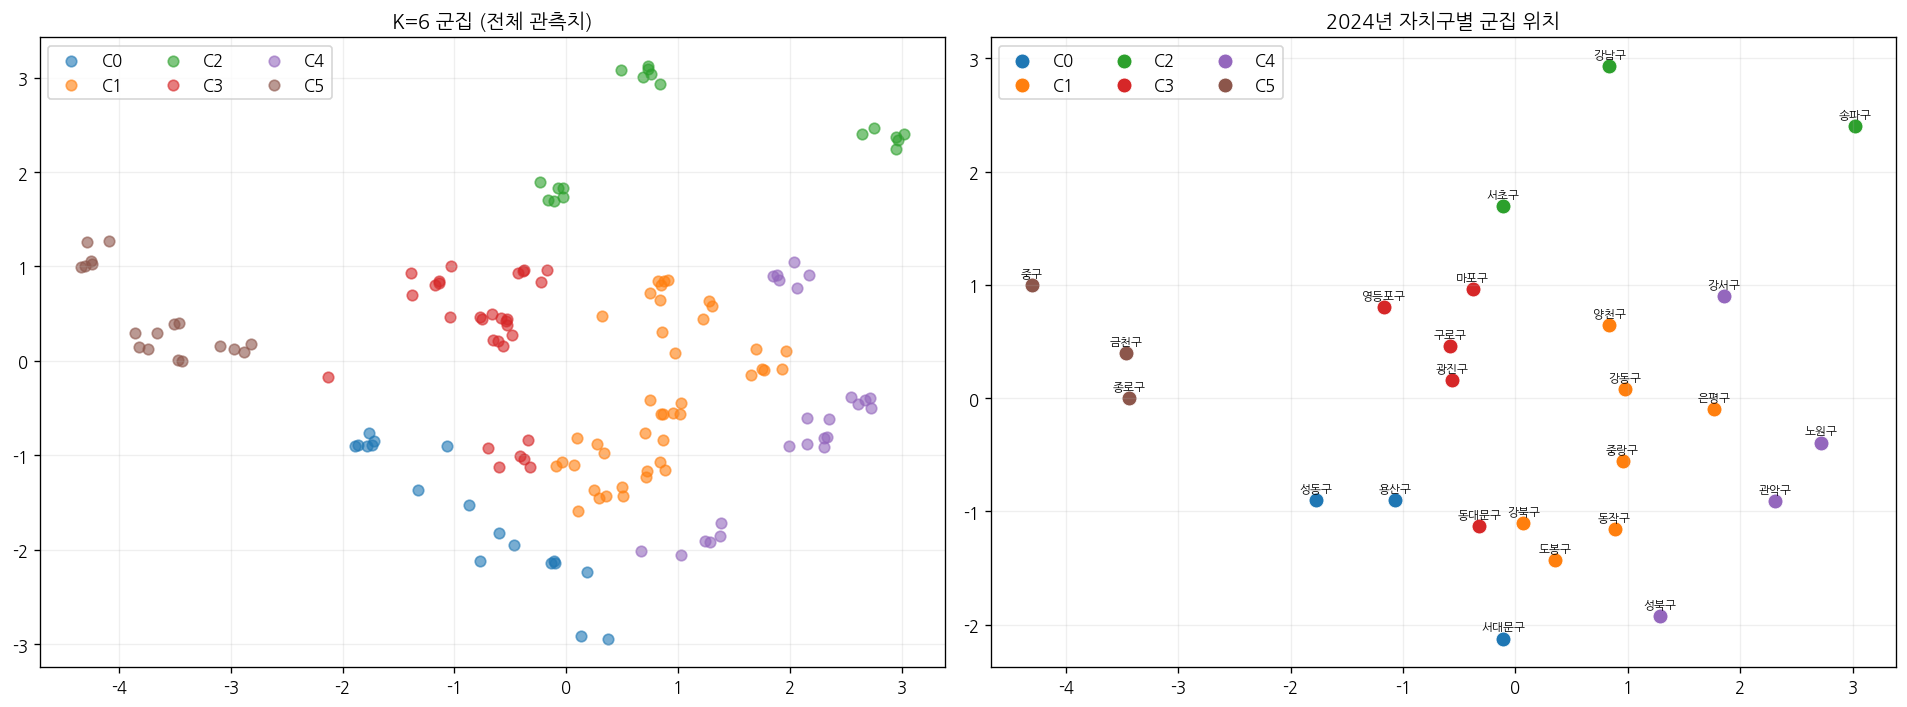


2024년 군집별 자치구:
  C0: 서대문구, 성동구, 용산구
  C1: 강동구, 강북구, 도봉구, 동작구, 양천구, 은평구, 중랑구
  C2: 강남구, 서초구, 송파구
  C3: 광진구, 구로구, 동대문구, 마포구, 영등포구
  C4: 강서구, 관악구, 노원구, 성북구
  C5: 금천구, 종로구, 중구


In [9]:
import seaborn as sns

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

df_pca = df_feat.copy()
df_pca['pc1'] = X_pca[:, 0]
df_pca['pc2'] = X_pca[:, 1]

print(f'PCA 설명 분산: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')

PALETTE = sns.color_palette('tab10', K_TARGET)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for cid in range(K_TARGET):
    m = df_pca.cluster == cid
    ax.scatter(df_pca.loc[m,'pc1'], df_pca.loc[m,'pc2'],
               c=[PALETTE[cid]], label=f'C{cid}', alpha=0.6, s=40)
ax.set_title(f'K={K_TARGET} 군집 (전체 관측치)')
ax.legend(ncol=3); ax.grid(alpha=0.2)

ax2 = axes[1]
df_2024 = df_pca[df_pca.year == 2024].copy()
for cid in range(K_TARGET):
    m = df_2024.cluster == cid
    ax2.scatter(df_2024.loc[m,'pc1'], df_2024.loc[m,'pc2'],
                c=[PALETTE[cid]], label=f'C{cid}', s=80, edgecolors='white', lw=0.5)
for _, row in df_2024.iterrows():
    ax2.annotate(row['district'], (row['pc1'], row['pc2']),
                 fontsize=7, ha='center', va='bottom',
                 xytext=(0, 4), textcoords='offset points')
ax2.set_title('2024년 자치구별 군집 위치')
ax2.legend(ncol=3); ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f'\n2024년 군집별 자치구:')
for cid in sorted(df_2024.cluster.unique()):
    dists = sorted(df_2024[df_2024.cluster == cid]['district'].tolist())
    print(f'  C{cid}: {", ".join(dists)}')

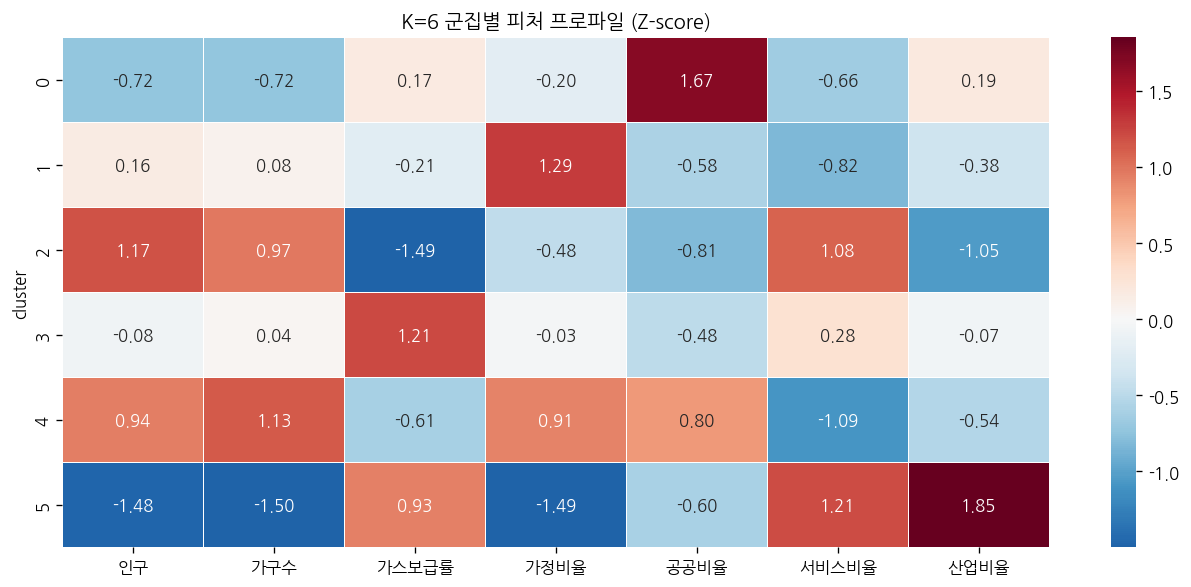

In [10]:
import seaborn as sns

cluster_means   = df_feat.groupby('cluster')[FEATURE_COLS].mean()
cluster_means_z = (cluster_means - cluster_means.mean()) / cluster_means.std()

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(cluster_means_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=['인구','가구수','가스보급률','가정비율','공공비율','서비스비율','산업비율'],
            ax=ax, linewidths=0.5)
ax.set_title(f'K={K_TARGET} 군집별 피처 프로파일 (Z-score)')
plt.tight_layout()
plt.show()

---
## 5. 군집 할당 결과 저장

In [11]:
OUT_PATH = 'data/cluster_assignments.csv'
save_df = df_feat[['year', 'district', 'cluster']].copy()
save_df.to_csv(OUT_PATH, index=False, encoding='utf-8-sig')

verify = pd.read_csv(OUT_PATH, encoding='utf-8-sig')
assert verify.shape == save_df.shape

print(f'✅ 저장 완료: {OUT_PATH}  (K={K_TARGET})')
print(f'   shape: {save_df.shape}')
print()
print('다음 단계: val_03_stability.ipynb 또는 val_04_timeline.ipynb 실행')

✅ 저장 완료: data/cluster_assignments.csv  (K=6)
   shape: (150, 3)

다음 단계: val_03_stability.ipynb 또는 val_04_timeline.ipynb 실행
